# JaxQSOFit Tutorial: SDSS Example + PSF Photometric Recalibration

This notebook mirrors the main SDSS tutorial, but also:

- queries SDSS PSF magnitudes for the same object
- fits the spectrum without PSF photometry
- fits the spectrum again with `use_psf_phot=True`
- compares the fiber-only and PSF-constrained results

This notebook demonstrates a joint spectral-plus-photometric calibration scheme in JaxQSOFit that connects the SDSS fiber spectrum to broadband PSF photometry. The spectrum is fit on its native fiber scale, while a second likelihood compares synthetic PSF magnitudes from a PSF-space version of the model to the observed SDSS PSF magnitudes. In that PSF-space model, a gray offset term delta_m_psf captures overall spectrophotometric or epoch-to-epoch normalization differences, while a host-suppression term eta_psf reduces the contribution of the extended host galaxy relative to the unresolved AGN. The key idea is that the AGN and host have different spectral shapes: the AGN continuum is typically bluer and smoother, while the host galaxy spectrum is redder and has stellar features. Because of this wavelength dependence, changing the host contribution does not simply rescale the total spectrum, it changes the broadband colors in a characteristic way. By fitting the fiber spectrum and the PSF photometry simultaneously, the model can use those color differences to separate AGN and host light more cleanly, infer PSF-consistent AGN and host components, and estimate more realistic host fractions in the photometric aperture.

We model the observed SDSS fiber spectrum and the SDSS PSF photometry jointly.

For the rest-frame spectral model, we write

$$
f_{\mathrm{fiber}}(\lambda)
=
f_{\mathrm{AGN}}(\lambda)
+
f_{\mathrm{host}}(\lambda)
+
f_{\mathrm{lines}}(\lambda),
$$

where the AGN term includes the power law, Fe II, and Balmer continuum components.

The fiber-spectrum likelihood is

$$
F_i^{\mathrm{obs}}
\sim
\mathcal{N}\!\left(
f_{\mathrm{fiber}}(\lambda_i),
\,
\sigma_{\mathrm{tot},i}^2
\right),
$$

with total per-pixel uncertainty

$$
\sigma_{\mathrm{tot},i}^2
=
\sigma_i^2
+
\left(f_{\mathrm{frac}}\,|f_{\mathrm{fiber}}(\lambda_i)|\right)^2
+
\sigma_{\mathrm{add}}^2,
$$

where $\sigma_i$ is the measured spectral error, and $f_{\mathrm{frac}}$ and $\sigma_{\mathrm{add}}$ are fractional and additive jitter terms.

To compare with PSF photometry, we construct a PSF-space model

$$
f_{\mathrm{PSF}}(\lambda)
=
s_{\mathrm{PSF}}
\left[
f_{\mathrm{AGN}}(\lambda)
+
\eta_{\mathrm{PSF}}\,f_{\mathrm{host}}(\lambda)
+
f_{\mathrm{lines}}(\lambda)
\right],
$$

where

$$
s_{\mathrm{PSF}} = 10^{-0.4\,\Delta m_{\mathrm{PSF}}},
$$

$\Delta m_{\mathrm{PSF}}$ is a gray magnitude offset between the fiber spectral scale and the PSF photometric scale, and $\eta_{\mathrm{PSF}} \in [0,1]$ controls how much of the fiber host component contributes in the PSF aperture.

For each photometric band $b$, we compute a synthetic AB magnitude from the PSF-space model,

$$
m_b^{\mathrm{syn}}
=
-2.5\log_{10}\!\left(f_{\nu,b}\right)-48.60,
$$

with

$$
f_{\nu,b}
=
\frac{
\int f_{\lambda}^{\mathrm{PSF}}(\lambda)\,T_b(\lambda)\,\lambda\,d\lambda
}{
\int T_b(\lambda)\,c/\lambda\,d\lambda
},
$$

where $T_b(\lambda)$ is the filter transmission curve.

The PSF-photometry likelihood is then

$$
m_b^{\mathrm{obs}}
\sim
\mathcal{N}\!\left(
m_b^{\mathrm{syn}},
\,
\sigma_{m,b}^2 + \sigma_{\mathrm{phot,extra}}^2
\right),
$$

where $\sigma_{m,b}$ is the catalog magnitude uncertainty and $\sigma_{\mathrm{phot,extra}}$ is an additional photometric scatter term.

The full joint likelihood is

$$
\mathcal{L}
=
\prod_i
p\!\left(F_i^{\mathrm{obs}} \mid f_{\mathrm{fiber}}(\lambda_i)\right)
\;
\prod_b
p\!\left(m_b^{\mathrm{obs}} \mid m_b^{\mathrm{syn}}\right).
$$

A useful derived quantity is the PSF-space host fraction at wavelength $\lambda$,

$$
f_{\mathrm{host,PSF}}(\lambda)
=
\frac{f_{\mathrm{host}}^{\mathrm{PSF}}(\lambda)}
     {f_{\mathrm{AGN}}^{\mathrm{PSF}}(\lambda)+f_{\mathrm{host}}^{\mathrm{PSF}}(\lambda)}
=
\frac{\eta_{\mathrm{PSF}}\,f_{\mathrm{host}}(\lambda)}
     {f_{\mathrm{AGN}}(\lambda)+\eta_{\mathrm{PSF}}\,f_{\mathrm{host}}(\lambda)},
$$

since the overall gray scale factor $s_{\mathrm{PSF}}$ cancels in the ratio.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM
from speclite import filters as speclite_filters

from jaxqsofit import QSOFit, build_default_prior_config


## 1. Download one SDSS spectrum and query PSF magnitudes


In [ ]:
coord = SkyCoord(184.0307, -2.2383, unit='deg') # High host example

# coord = SkyCoord.from_name('SDSS J212805.25-005145.7') # Low host example

psf_bands_all = ['u', 'g', 'r', 'i', 'z']

photo_fields = [
    'ra', 'dec',
    *[f'psfMag_{b}' for b in psf_bands_all],
    *[f'psfMagErr_{b}' for b in psf_bands_all],
]
spec_fields = ['plate', 'mjd', 'fiberID', 'run2d']

xid = SDSS.query_region(
    coord,
    spectro=True,
    radius=5 * u.arcsec,
    photoobj_fields=photo_fields,
    specobj_fields=spec_fields,
)
if xid is None or len(xid) == 0:
    raise RuntimeError('No SDSS spectrum / photometry match found near the target coordinates.')

sp = SDSS.get_spectra(matches=xid[:1])[0]

tb = sp[1].data
lam = np.asarray(10 ** tb['loglam'], dtype=float)
flux = np.asarray(tb['flux'], dtype=float)
ivar = np.asarray(tb['ivar'], dtype=float)

err = np.full_like(flux, 1e-6)
m = np.isfinite(ivar) & (ivar > 0)
err[m] = 1.0 / np.sqrt(ivar[m])

z = float(sp[2].data['z'][0])
ra = float(coord.ra.deg)
dec = float(coord.dec.deg)

plate = int(sp[0].header.get('plateid', 0))
mjd = int(sp[0].header.get('mjd', 0))
fiber = int(sp[0].header.get('fiberid', 0))
sdss_filename = f"{plate:04d}-{mjd}-{fiber:04d}"

row = xid[0]


def get_row_value(row, name):
    for candidate in (name, name.lower(), name.upper()):
        if candidate in row.colnames:
            return row[candidate]
    raise KeyError(f'Column {name!r} not found in SDSS query result. Available columns: {row.colnames}')


psf_mags_all = np.array([float(get_row_value(row, f'psfMag_{b}')) for b in psf_bands_all], dtype=float)
psf_mag_errs_all = np.array([float(get_row_value(row, f'psfMagErr_{b}')) for b in psf_bands_all], dtype=float)

phot_table = pd.DataFrame({
    'band': psf_bands_all,
    'psf_mag': psf_mags_all,
    'psf_mag_err': psf_mag_errs_all,
})

print(f'Nspec pixels: {lam.size}')
print(f'z = {z:.5f}')
print(f'SDSS filename key: {sdss_filename}')
phot_table


Nspec pixels: 3810
z = 0.10061
SDSS filename key: 0332-52367-0639


,band,psf_mag,psf_mag_err
0,u,18.97159,0.026543
1,g,17.88367,0.021905
2,r,17.28335,0.012091
3,i,16.89238,0.011235
4,z,16.73258,0.017660


## 2. Build a default prior config


In [17]:
def make_prior_config(flux):
    prior_config = build_default_prior_config(flux)

    # Example override: slightly tighter PL slope and Fe normalization priors
    prior_config['PL_slope'] = {'loc': -1.5, 'scale': 0.3, 'low': -3.5, 'high': 0.5}
    prior_config['log_Fe_uv_norm'] = {
        'loc': np.log(max(1e-3 * np.median(np.abs(flux)), 1e-10)),
        'scale': 0.4,
    }
    prior_config['log_Fe_op_over_uv'] = {'loc': 0.0, 'scale': 0.4}

    # Robust line scale multipliers (optional)
    prior_config['line_dmu_scale_mult'] = 0.25
    prior_config['line_sig_scale_mult'] = 0.25
    prior_config['line_amp_scale_mult'] = 0.20
    return prior_config


prior_config = make_prior_config(flux)


## 3. Run a baseline fit without PSF recalibration


In [ ]:
q_nocal = QSOFit(
    lam=lam,
    flux=flux,
    err=err,
    z=z,
    ra=ra,
    dec=dec,
    filename=sdss_filename + '_fiber_only',
    output_path='.',
)

q_nocal.fit(
    deredden=True,
    fit_method='optax+nuts',
    fit_lines=True,
    decompose_host=True,
    fit_fe=True,
    fit_bc=False,
    fit_poly=True,
    fsps_age_grid=(0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0),
    fsps_logzsol_grid=(-1.0, -0.5, 0.0, 0.2),
    prior_config=make_prior_config(flux),
    dsps_ssp_fn='../tempdata.h5',
    optax_steps=600,
    optax_lr=1e-2,
    nuts_warmup=50,
    nuts_samples=50,
    nuts_chains=1,
    plot_fig=True,
    save_fig=False,
    save_result=False,
    use_psf_phot=False,
)


100%|██████████| 200/200 [00:01<00:00, 185.87it/s, init loss: 41512.7366, avg. loss [191-200]: 18813.4917]


## 4. Run a fit with SDSS PSF photometry


100%|██████████| 200/200 [00:01<00:00, 125.17it/s, init loss: 19691.6332, avg. loss [191-200]: 9625.3713] 


100%|██████████| 400/400 [00:03<00:00, 113.53it/s, init loss: 1501211.2166, avg. loss [381-400]: 7406.4697]  


max data        : 54.75692836911077
max total model : 26.978496674757178
max PL          : 19.768293605437155
max host        : 1.052221363108316
max FeII UV     : 0.024699534296251845
max FeII opt    : 0.03208997983036201
max Balmer cont : 0.0
max lines       : 8.431206623142105


sample: 100%|██████████| 100/100 [01:25<00:00,  1.17it/s, 255 steps of size 1.48e-02. acc. prob=0.96]


max data        : 54.75692836911077
max total model : 32.57732619657064
max PL          : 22.153563984101204
max host        : 0.33032439535604535
max FeII UV     : 0.005792319744456256
max FeII opt    : 0.004585123699485796
max Balmer cont : 0.0
max lines       : 10.571832502752333
Bands kept by the PSF photometry likelihood: ['g', 'r', 'i', 'z']


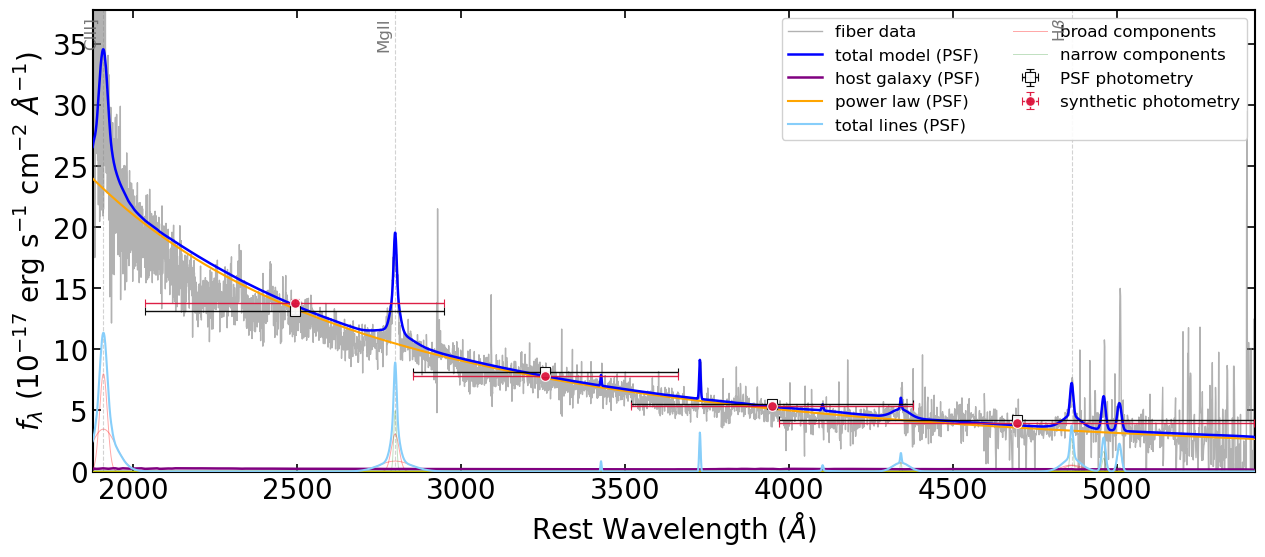

In [ ]:
q_psf = QSOFit(
    lam=lam,
    flux=flux,
    err=err,
    z=z,
    ra=ra,
    dec=dec,
    filename=sdss_filename + '_psf_recal',
    output_path='.',
)

q_psf.fit(
    deredden=True,
    fit_method='optax+nuts',
    fit_lines=True,
    decompose_host=True,
    fit_fe=True,
    fit_bc=False,
    fit_poly=True,
    fsps_age_grid=(0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0),
    fsps_logzsol_grid=(-1.0, -0.5, 0.0, 0.2),
    prior_config=make_prior_config(flux),
    dsps_ssp_fn='../tempdata.h5',
    optax_steps=600,
    optax_lr=1e-2,
    nuts_warmup=50,
    nuts_samples=50,
    nuts_chains=1,
    plot_fig=True,
    save_fig=False,
    save_result=False,
    psf_mags=psf_mags_all,
    psf_mag_errs=psf_mag_errs_all,
    psf_bands=psf_bands_all,
    use_psf_phot=True,
    kwargs_plot={'plot_residual': True, 'plot_psf_space': True},
)

print('Bands kept by the PSF photometry likelihood:', getattr(q_psf, 'psf_bands', None))


Fiber spectrum (below), compared to PSF spectrum (above)

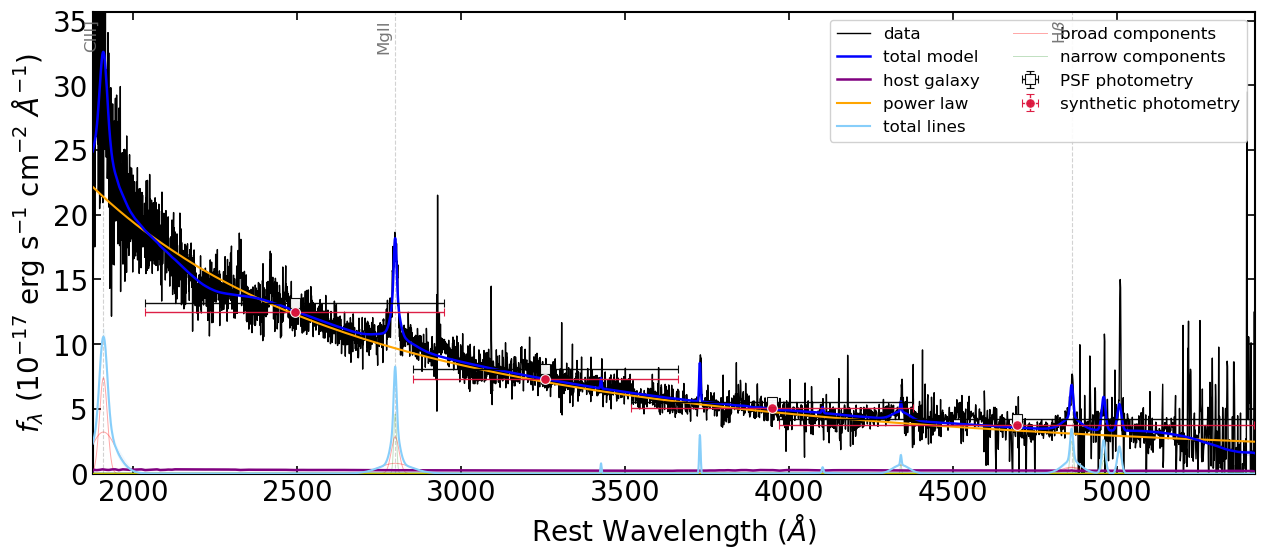

In [ ]:
q_psf.plot_fig(plot_residual=False, plot_psf_space=False)

## 5. Compare fit-quality and host-decomposition summaries


In [ ]:
def fit_stats(q):
    resid = np.asarray(q.flux) - np.asarray(q.model_total)
    sigma = np.asarray(q.err)

    if getattr(q, 'numpyro_samples', None) is not None:
        s = q.numpyro_samples
        frac_j = float(np.median(np.asarray(s.get('frac_jitter', 0.0))))
        add_j = float(np.median(np.asarray(s.get('add_jitter', 0.0))))
        sigma = np.sqrt(sigma**2 + (frac_j * np.abs(np.asarray(q.model_total)))**2 + add_j**2)

    m = np.isfinite(resid) & np.isfinite(sigma) & (sigma > 0)
    zres = resid[m] / sigma[m]

    return {
        'chi2': float(np.sum(zres**2)),
        'chi2_per_pixel': float(np.mean(zres**2)),
        'wrms': float(np.sqrt(np.mean(zres**2))),
        'frac_host_2500': float(getattr(q, 'frac_host_2500', np.nan)),
        'frac_host_4200': float(getattr(q, 'frac_host_4200', np.nan)),
        'delta_m_psf': float(getattr(q, 'delta_m_psf', np.nan)),
        'eta_psf': float(getattr(q, 'eta_psf', np.nan)),
        'scale_psf': float(getattr(q, 'scale_psf', np.nan)),
    }


summary = pd.DataFrame({
    'fiber_only': fit_stats(q_nocal),
    'with_psf_phot': fit_stats(q_psf),
}).T

summary


,chi2,chi2_per_pixel,wrms,frac_host_2500,frac_host_4200,delta_m_psf,eta_psf,scale_psf
fiber_only,12308.121779,2.669296,1.633798,0.016462,0.045127,0.000000,1.000000,1.000000
with_psf_phot,11752.151055,2.548721,1.596471,0.022035,0.058887,-0.086236,0.757465,1.082666


## 6. Compare the fitted fiber-space models directly


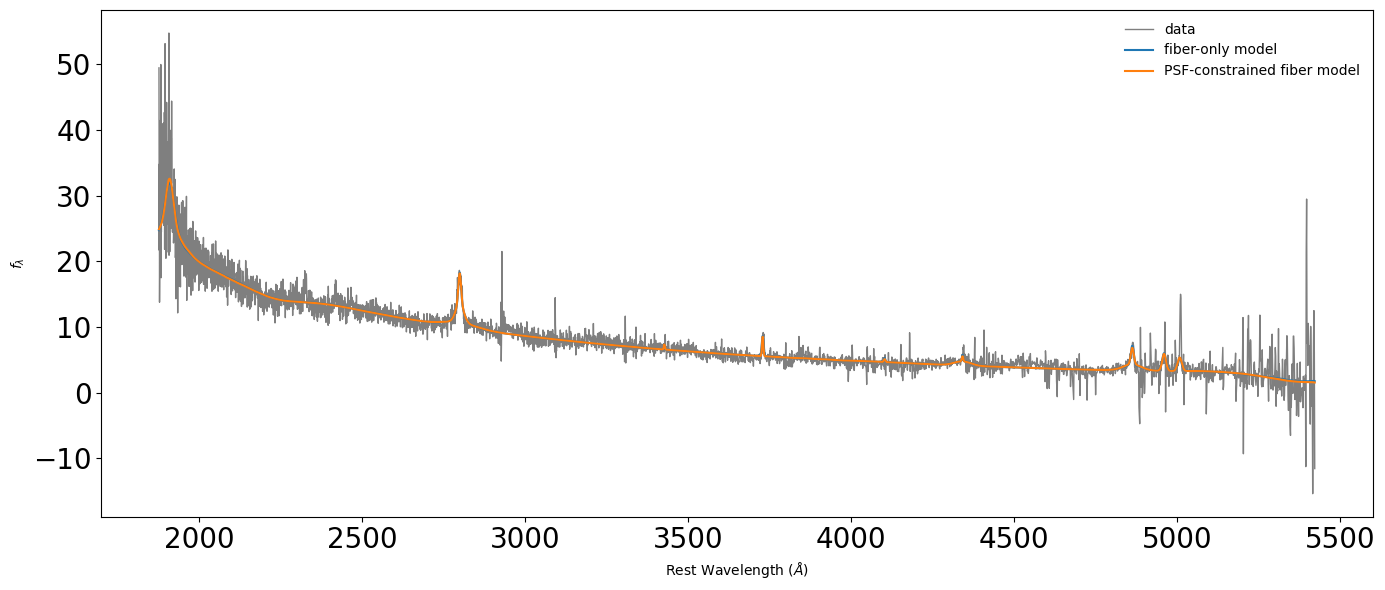

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(q_nocal.wave, q_nocal.flux, color='k', lw=1.0, alpha=0.5, label='data')
ax.plot(q_nocal.wave, q_nocal.model_total, color='tab:blue', lw=1.5, label='fiber-only model')
ax.plot(q_psf.wave, q_psf.model_total, color='tab:orange', lw=1.5, label='PSF-constrained fiber model')
ax.set_xlabel(r'Rest Wavelength ($\AA$)')
ax.set_ylabel(r'$f_\lambda$')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 8. Inspect PSF-specific posterior quantities


In [ ]:
for name in ['delta_m_psf', 'delta_m_psf_err', 'eta_psf', 'eta_psf_err', 'scale_psf']:
    print(f'{name:18s}:', getattr(q_psf, name, np.nan))


delta_m_psf       : -0.08623585155898528
delta_m_psf_err   : 0.04049867623405518
eta_psf           : 0.7574646040089619
eta_psf_err       : 0.03470262429507639
scale_psf         : 1.0826656066079252
